In [1]:
import pandas as pd

# 이 파일은 실제 컬럼명이 둘째 줄에 있어서 header=1로 읽는다
df = pd.read_csv("../../data/default_of_credit_card_clients.csv", header=1)

print("행 수, 열 수:", df.shape)
df.head()

행 수, 열 수: (30000, 25)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [2]:
# SEX, EDUCATION, MARRIAGE는 숫자로 적혀 있지만 실제로는 범주형이라 원-핫 인코딩한다
범주형열 = ["SEX", "EDUCATION", "MARRIAGE"]

print("인코딩 전 열 수:", df.shape[1])
print("범주형 열의 고유값 개수:", {c: df[c].nunique() for c in 범주형열})

df_인코딩 = pd.get_dummies(df, columns=범주형열, prefix=범주형열)

print()
print("인코딩 후 열 수:", df_인코딩.shape[1])
새로생긴열 = [c for c in df_인코딩.columns if c not in df.columns]
print("새로 생긴 열:", 새로생긴열)

인코딩 전 열 수: 25
범주형 열의 고유값 개수: {'SEX': 2, 'EDUCATION': 7, 'MARRIAGE': 4}

인코딩 후 열 수: 35
새로 생긴 열: ['SEX_1', 'SEX_2', 'EDUCATION_0', 'EDUCATION_1', 'EDUCATION_2', 'EDUCATION_3', 'EDUCATION_4', 'EDUCATION_5', 'EDUCATION_6', 'MARRIAGE_0', 'MARRIAGE_1', 'MARRIAGE_2', 'MARRIAGE_3']


## Q2. 파생변수 만들기

In [3]:
import numpy as np

pay_cols = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]
bill_cols = [f"BILL_AMT{i}" for i in range(1, 7)]
payamt_cols = [f"PAY_AMT{i}" for i in range(1, 7)]

# 6개월 평균 청구액 / 납부액
df["평균청구액"] = df[bill_cols].mean(axis=1)
df["평균납부액"] = df[payamt_cols].mean(axis=1)

# 이용률 - 한도 대비 평균 청구액이 얼마나 되는지
df["이용률"] = df["평균청구액"] / df["LIMIT_BAL"]

# 상환율 - 평균 청구액 대비 평균 납부액. 청구액이 0인 경우는 나눌 수 없어 결측으로 둔다
청구액0 = df["평균청구액"] == 0
df["상환율"] = np.where(청구액0, np.nan, df["평균납부액"] / df["평균청구액"])

# 평균 연체월수 - PAY_0~PAY_6의 평균 (음수/0은 연체가 아니고, 양수일수록 연체가 길다)
df["평균연체월수"] = df[pay_cols].mean(axis=1)

파생열 = ["이용률", "상환율", "평균연체월수"]
print(df[파생열].describe())
print()
print("상환율 결측치(청구액 0):", df["상환율"].isna().sum(), "건")

print()
y = df["default payment next month"]
비교 = df.groupby(y)[파생열].mean()
비교.index = ["정상(0)", "불이행(1)"]
print(비교.round(3))

                이용률           상환율        평균연체월수
count  30000.000000  29130.000000  30000.000000
mean       0.373048      0.392318     -0.182439
std        0.351890      7.784430      0.982176
min       -0.232590   -546.928571     -2.000000
25%        0.029997      0.042188     -0.833333
50%        0.284834      0.092133      0.000000
75%        0.687929      0.615363      0.000000
max        5.364308    797.000000      6.000000

상환율 결측치(청구액 0): 870 건

          이용률    상환율  평균연체월수
정상(0)   0.351  0.439  -0.330
불이행(1)  0.449  0.224   0.337


### 알게 된 것 (실행 결과 기준)

불이행(1) 그룹은 정상(0) 그룹보다 이용률이 높고(0.449 vs 0.351) 상환율은 낮으며(0.224 vs 0.439) 평균 연체월수도 더 크다(0.337 vs -0.330) — 세 파생변수 모두 방향이 일관돼 있어 default 예측에 쓸모 있어 보인다.

## Q3. 상환율 다듬기

실제로 쓰려면 두 가지 문제를 처리해야 한다.
1. **청구액이 0 이하인 경우** — 청구액이 0(870건)이거나 과납으로 마이너스(201건)인 경우 "납부액/청구액" 자체가 뜻이 없다. 이런 자리는 비율을 계산하지 말고 결측으로 남긴다.
2. **극단값(outlier)** — 청구액이 0에 가까운 나머지 자리에서는 비율이 최대 797까지 튀어 표준편차가 7.78까지 벌어진다. 상한을 99번째 백분위수로 클리핑(clip)해서 극단값의 영향을 줄인다.

In [4]:
# 1. 청구액이 0 이하(0이거나 과납으로 마이너스)면 비율 자체가 의미 없으니 결측으로 둔다
청구액이하0 = df["평균청구액"] <= 0
print("평균청구액 <= 0 인 건수:", 청구액이하0.sum(),
      "(0인 것:", (df["평균청구액"] == 0).sum(), "/ 마이너스인 것:", (df["평균청구액"] < 0).sum(), ")")

df["상환율"] = np.where(청구액이하0, np.nan, df["평균납부액"] / df["평균청구액"])
print("결측 처리 후 상환율 결측치:", df["상환율"].isna().sum(), "건")
print(df["상환율"].describe())

# 2. 남은 값 중에서도 극단값이 있으니 99번째 백분위수로 상한을 클리핑한다
상한 = df["상환율"].quantile(0.99)
print()
print("클리핑 상한(99번째 백분위수):", round(상한, 3))

df["상환율_클립"] = df["상환율"].clip(lower=0, upper=상한)
print(df["상환율_클립"].describe())

print()
y = df["default payment next month"]
비교 = df.groupby(y)[["이용률", "상환율_클립", "평균연체월수"]].mean()
비교.index = ["정상(0)", "불이행(1)"]
print(비교.round(3))

평균청구액 <= 0 인 건수: 1071 (0인 것: 870 / 마이너스인 것: 201 )
결측 처리 후 상환율 결측치: 1071 건
count    28929.000000
mean         0.486527
std          5.606963
min          0.000000
25%          0.042515
50%          0.094530
75%          0.622939
max        797.000000
Name: 상환율, dtype: float64

클리핑 상한(99번째 백분위수): 2.82
count    28929.000000
mean         0.368291
std          0.498688
min          0.000000
25%          0.042515
50%          0.094530
75%          0.622939
max          2.819814
Name: 상환율_클립, dtype: float64

          이용률  상환율_클립  평균연체월수
정상(0)   0.351   0.394  -0.330
불이행(1)  0.449   0.275   0.337


### 인사이트 (실행 결과 기준)

결측 처리로 1071건(청구액 0 또는 마이너스)을 제외하고, 남은 값을 99번째 백분위수(2.82)로 클리핑했더니 표준편차가 7.78 → 0.50, 최댓값이 797 → 2.82로 안정됐다. 그런데도 정상/불이행 그룹 간 차이(0.394 vs 0.275)는 클리핑 전(0.439 vs 0.224)과 방향·크기가 거의 그대로 유지돼, 이 다듬기가 신호를 죽이지 않고 노이즈만 걷어낸 것으로 보인다.

## Q4. 상관관계로 피처 추리기

In [5]:
# 범주형은 원-핫으로, 나머지는 지금까지 만든 df 그대로 합쳐서 상관관계를 잰다
df_전체 = pd.get_dummies(df, columns=범주형열, prefix=범주형열)

제외 = ["ID", "default payment next month", "상환율"]  # 상환율(클립 전)은 상환율_클립과 중복이라 뺀다
특성열 = [c for c in df_전체.columns if c not in 제외]

# corrwith - 정답 열과 각 특성 열의 상관계수를 한 번에 구한다
상관 = df_전체[특성열].corrwith(df_전체["default payment next month"])

# 절대값(방향은 무시하고 세기만) 기준으로 내림차순 정렬. 동점 처리를 위해 mergesort
상관표 = pd.DataFrame({"상관계수": 상관, "절대값": 상관.abs()}).sort_values(
    "절대값", ascending=False, kind="mergesort")

print(상관표.head(15).round(4))

             상관계수     절대값
PAY_0      0.3248  0.3248
평균연체월수     0.2820  0.2820
PAY_2      0.2636  0.2636
PAY_3      0.2353  0.2353
PAY_4      0.2166  0.2166
PAY_5      0.2041  0.2041
PAY_6      0.1869  0.1869
LIMIT_BAL -0.1535  0.1535
이용률        0.1155  0.1155
평균납부액     -0.1024  0.1024
상환율_클립    -0.0985  0.0985
PAY_AMT1  -0.0729  0.0729
PAY_AMT2  -0.0586  0.0586
PAY_AMT4  -0.0568  0.0568
PAY_AMT3  -0.0563  0.0563


### 알게 된 것 (실행 결과 기준)

- 가장 상관 높은 열은 **가장 최근 달 연체 상태(`PAY_0`, 0.3248)**이고, 그 뒤를 **Q2에서 만든 파생변수 `평균연체월수`(0.2820)**가 잇는다 — 원본 열 하나보다 6개월을 요약한 파생변수가 두 번째로 강한 신호라는 뜻
- `PAY_0`부터 `PAY_6`까지 최근 달일수록 상관이 크고(0.3248 → 0.1869) 갈수록 약해진다 — **최근 연체 이력이 오래된 연체보다 다음 달 불이행을 더 잘 설명**한다
- `LIMIT_BAL`은 음의 상관(-0.1535)이라 **한도가 높을수록 불이행 가능성이 낮다**
- `이용률`(0.1155)은 양의 상관, `평균납부액`(-0.1024)·`상환율_클립`(-0.0985)은 음의 상관 — Q2~Q3에서 만든 세 파생변수가 모두 상위 11위 안에 들어 원본 청구·납부 열 대부분보다 상관이 강하다

## Q5. 불균형 대응 비교 — class_weight="balanced" 효과가 SECOM만큼 극적인가

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score, f1_score

X = df_전체[특성열].fillna(df_전체[특성열].median())
y = df_전체["default payment next month"]

print("전체 불이행 비율:", round(y.mean() * 100, 2), "%")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

scaler = StandardScaler()
X_train_스케일 = scaler.fit_transform(X_train)
X_test_스케일 = scaler.transform(X_test)

결과 = {}
for 이름, class_weight in [("손 안 댐", None), ("가중치", "balanced")]:
    모델 = LogisticRegression(max_iter=1000, class_weight=class_weight)
    모델.fit(X_train_스케일, y_train)
    예측 = 모델.predict(X_test_스케일)

    맞힌정상, 헛경보, 놓친불이행, 잡은불이행 = confusion_matrix(y_test, 예측).ravel()
    정확도 = accuracy_score(y_test, 예측)
    재현율 = recall_score(y_test, 예측)
    정밀도 = precision_score(y_test, 예측)
    f1 = f1_score(y_test, 예측)
    결과[이름] = (정확도, 잡은불이행, 놓친불이행, 헛경보, 재현율, 정밀도, f1)

    print(f"[{이름}] 정확도 {round(정확도*100,2)}% "
          f"잡은불이행 {잡은불이행} 놓친불이행 {놓친불이행} 헛경보 {헛경보} "
          f"재현율 {round(재현율,3)} 정밀도 {round(정밀도,3)} F1 {round(f1,3)}")

전체 불이행 비율: 22.12 %
[손 안 댐] 정확도 81.02% 잡은불이행 331 놓친불이행 996 헛경보 143 재현율 0.249 정밀도 0.698 F1 0.368
[가중치] 정확도 69.8% 잡은불이행 806 놓친불이행 521 헛경보 1291 재현율 0.607 정밀도 0.384 F1 0.471


### 알게 된 것 (실행 결과 기준, SECOM 수치는 `day04/lab10_imbalance` 노트북에서 이미 실행된 값을 그대로 인용)

| 데이터 | 불량률 | 손 안 댐 정확도 | 손 안 댐 재현율 | 가중치 정확도 | 가중치 재현율 | 정확도 하락폭 | 재현율 증가 배수 |
|---|---|---|---|---|---|---|---|
| SECOM | 6.64% | 93.95% | 0.095 | 74.84% | 0.476 | 19.11%p | 5.01배 |
| 신용카드 | 22.12% | 81.02% | 0.249 | 69.80% | 0.607 | 11.22%p | 2.44배 |

- **정확도 하락폭**은 신용카드가 11.22%p로 SECOM(19.11%p)의 약 절반이다 — 정확도 측면에서는 예상대로 22%가 6.6%보다 덜 극적이다.
- **재현율 증가를 배수로 보면** SECOM은 5.01배, 신용카드는 2.44배로 SECOM이 훨씬 크다.
- 다만 **재현율의 절대 증가폭**은 SECOM +0.381, 신용카드 +0.358로 거의 비슷하다 — "덜 극적이다"는 배수·정확도 기준에서는 맞지만, 재현율을 몇 %p 올렸는지로만 보면 두 데이터의 차이가 크지 않다.

## Q6. 상관관계 그래프로 보기

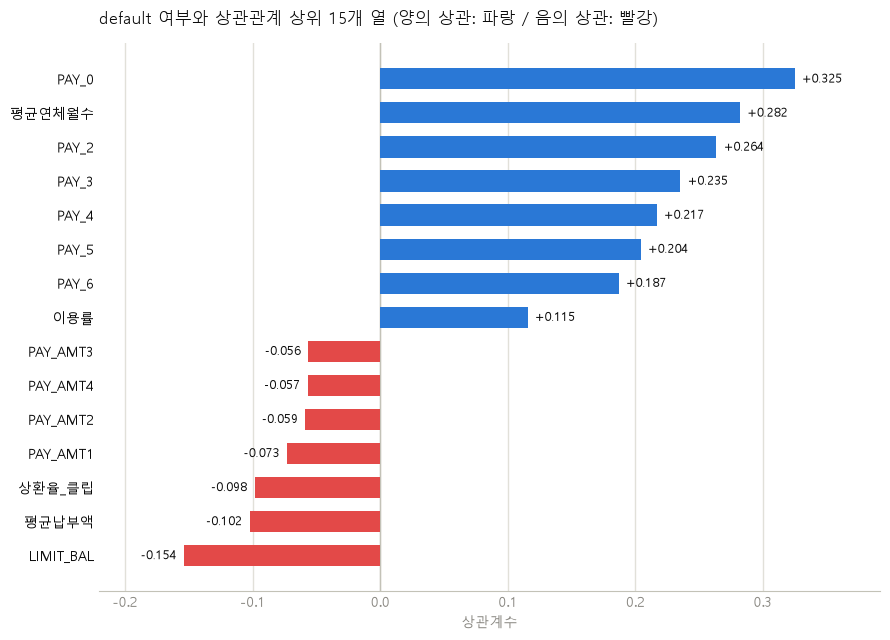

In [7]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

POS = "#2a78d6"   # 양의 상관
NEG = "#e34948"   # 음의 상관
GRID = "#e1e0d9"
AXIS = "#c3c2b7"
MUTED = "#898781"
INK = "#0b0b0b"

# Q4에서 만든 상관표 상위 15개를, 이번엔 부호 순으로 다시 정렬해서 위아래로 갈린 모습을 본다
top = 상관표.head(15).sort_values("상관계수", kind="mergesort")

fig, ax = plt.subplots(figsize=(9, 6.5))
colors = [POS if v >= 0 else NEG for v in top["상관계수"]]
bars = ax.barh(top.index, top["상관계수"], color=colors, height=0.62, zorder=3)

ax.axvline(0, color=AXIS, linewidth=1, zorder=2)
ax.xaxis.grid(True, color=GRID, linewidth=1, zorder=0)
ax.set_axisbelow(True)

for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)
ax.spines["bottom"].set_color(AXIS)
ax.tick_params(axis="y", colors=INK, length=0)
ax.tick_params(axis="x", colors=MUTED, length=0)

# 막대 끝 라벨이 y축 눈금과 겹치지 않도록 여백을 넉넉히 둔다
최소값 = min(0, top["상관계수"].min())
최대값 = max(0, top["상관계수"].max())
여백 = (최대값 - 최소값) * 0.14
ax.set_xlim(최소값 - 여백, 최대값 + 여백)

for bar, v in zip(bars, top["상관계수"]):
    x = bar.get_width()
    offset = 0.006 if x >= 0 else -0.006
    ha = "left" if x >= 0 else "right"
    ax.text(x + offset, bar.get_y() + bar.get_height() / 2, f"{v:+.3f}",
             va="center", ha=ha, fontsize=9, color=INK)

ax.set_title("default 여부와 상관관계 상위 15개 열 (양의 상관: 파랑 / 음의 상관: 빨강)",
             fontsize=12, color=INK, loc="left", pad=14)
ax.set_xlabel("상관계수", color=MUTED, fontsize=10)

fig.tight_layout()
plt.show()

### 인사이트 (실행 결과 기준)

음의 상관 7개 중 5개(`PAY_AMT1~4`, `평균납부액`)가 "얼마나 냈는지"를 나타내는 열이고, 나머지 2개(`LIMIT_BAL`, `상환율_클립`)는 "얼마나 여유가 있는지"를 나타낸다 — 반대로 양의 상관 상위는 전부 "연체 이력"(`PAY_0~6`, `평균연체월수`)과 `이용률`이다. 즉 이 데이터에서 default를 가르는 축은 뚜렷이 둘로 나뉜다: **연체를 얼마나 했는가(양의 상관)** 대 **얼마나 갚고 여유가 있는가(음의 상관)**.

### Q6 그래프, 비전문가용 설명

**상관계수가 뭔지부터.** 어떤 열과 "다음 달에 카드값을 못 갚는다(default)"가 **같이 움직이는 정도**를 -1~+1 사이 숫자 하나로 나타낸 것이다. 0이면 둘이 아무 관계가 없다는 뜻이고, +1에 가까울수록 "그 열 값이 클수록 불이행도 늘어난다", -1에 가까울수록 "그 열 값이 클수록 불이행은 줄어든다"는 뜻이다. 이 그래프의 막대 15개는 이 신용카드 데이터에서 상관계수의 절댓값(부호를 뺀 크기)이 가장 큰 15개 열을 고른 것이다.

**막대를 읽는 법.** 막대가 **오른쪽(파랑)** 으로 뻗으면 그 열이 커질수록 불이행 가능성도 커진다는 뜻이고, **왼쪽(빨강)** 으로 뻗으면 그 열이 커질수록 오히려 불이행 가능성이 줄어든다는 뜻이다. 막대가 길수록(0에서 멀수록) 그 관계가 더 뚜렷하다.

**이 그래프에서 실제로 보이는 것.**
- 가장 긴 막대(오른쪽)는 `PAY_0`(가장 최근 달 연체 상태)다 — **최근에 카드값을 늦게 낸 사람일수록 다음 달에도 못 낼 가능성이 크다**는, 상식과 맞아떨어지는 결과가 숫자로도 확인된다.
- 왼쪽(빨강) 막대들은 전부 "얼마나 냈는지·얼마나 여유가 있는지"에 관한 열이다(카드 한도, 실제로 낸 금액 등) — **돈을 많이 냈거나 한도가 넉넉한 사람일수록 못 갚을 가능성이 낮다**는 뜻이다.
- 즉 이 그래프 하나로 "이 데이터에서 다음 달 연체를 가장 잘 예고하는 신호는 연체 이력이고, 그 반대편에는 상환 여력이 있다"는 것을 한눈에 알 수 있다.

## Q7. 개인별 6개월 흐름 보기 — wide→long

In [8]:
# PAY_6(6개월 전) ~ PAY_0(이번 달) 순서로 시간순 배열
pay_순서 = ["PAY_6", "PAY_5", "PAY_4", "PAY_3", "PAY_2", "PAY_0"]
월이름 = {"PAY_6": "6개월 전", "PAY_5": "5개월 전", "PAY_4": "4개월 전",
        "PAY_3": "3개월 전", "PAY_2": "2개월 전", "PAY_0": "이번 달"}

# wide -> long: 한 고객이 여섯 줄(한 달에 한 줄)이 되도록 펼친다
long = df[["ID", "default payment next month"] + pay_순서].melt(
    id_vars=["ID", "default payment next month"],
    value_vars=pay_순서,
    var_name="열이름",
    value_name="연체상태"
)
long["월"] = long["열이름"].map(월이름)
long["월순서"] = long["열이름"].map({c: i for i, c in enumerate(pay_순서)})
long = long.sort_values(["ID", "월순서"], kind="mergesort")

print("long 모양:", long.shape, "(원래 30000행 x 6개월 = 180000행이 맞는지 확인)")
print(long.head(6))
print()

# 월별 평균 연체상태를 default 그룹별로 비교
월별평균 = (long.groupby(["월순서", "월", "default payment next month"])["연체상태"]
           .mean().reset_index())
피벗 = (월별평균.pivot(index=["월순서", "월"], columns="default payment next month", values="연체상태")
       .reset_index().sort_values("월순서"))
피벗.columns = ["월순서", "월", "정상(0)", "불이행(1)"]
print(피벗[["월", "정상(0)", "불이행(1)"]].round(3))

long 모양: (180000, 6) (원래 30000행 x 6개월 = 180000행이 맞는지 확인)
        ID  default payment next month    열이름  연체상태      월  월순서
0        1                           1  PAY_6    -2  6개월 전    0
30000    1                           1  PAY_5    -2  5개월 전    1
60000    1                           1  PAY_4    -1  4개월 전    2
90000    1                           1  PAY_3    -1  3개월 전    3
120000   1                           1  PAY_2     2  2개월 전    4
150000   1                           1  PAY_0     2   이번 달    5

       월  정상(0)  불이행(1)
0  6개월 전 -0.406   0.112
1  5개월 전 -0.389   0.168
2  4개월 전 -0.356   0.255
3  3개월 전 -0.316   0.362
4  2개월 전 -0.302   0.458
5   이번 달 -0.211   0.668


In [9]:
# 고객별로 초반 3개월 평균 vs 후반 3개월 평균을 비교해 "악화 정도"를 잰다
wide = df.set_index("ID")[pay_순서]
초반3개월 = wide[["PAY_6", "PAY_5", "PAY_4"]].mean(axis=1)
후반3개월 = wide[["PAY_3", "PAY_2", "PAY_0"]].mean(axis=1)
악화정도 = 후반3개월 - 초반3개월

y = df.set_index("ID")["default payment next month"]
개인별 = pd.DataFrame({"초반3개월평균": 초반3개월, "후반3개월평균": 후반3개월,
                     "악화정도": 악화정도, "default": y})

그룹평균 = 개인별.groupby("default")[["초반3개월평균", "후반3개월평균", "악화정도"]].mean()
그룹평균.index = ["정상(0)", "불이행(1)"]
print(그룹평균.round(3))
print()

악화비율 = (개인별["악화정도"] > 0).groupby(개인별["default"]).mean()
악화비율.index = ["정상(0)", "불이행(1)"]
print("후반이 초반보다 나빠진(악화된) 고객 비율:")
print(악화비율.round(3))

        초반3개월평균  후반3개월평균   악화정도
정상(0)    -0.384   -0.276  0.107
불이행(1)    0.178    0.496  0.318

후반이 초반보다 나빠진(악화된) 고객 비율:
정상(0)     0.261
불이행(1)    0.451
Name: 악화정도, dtype: float64


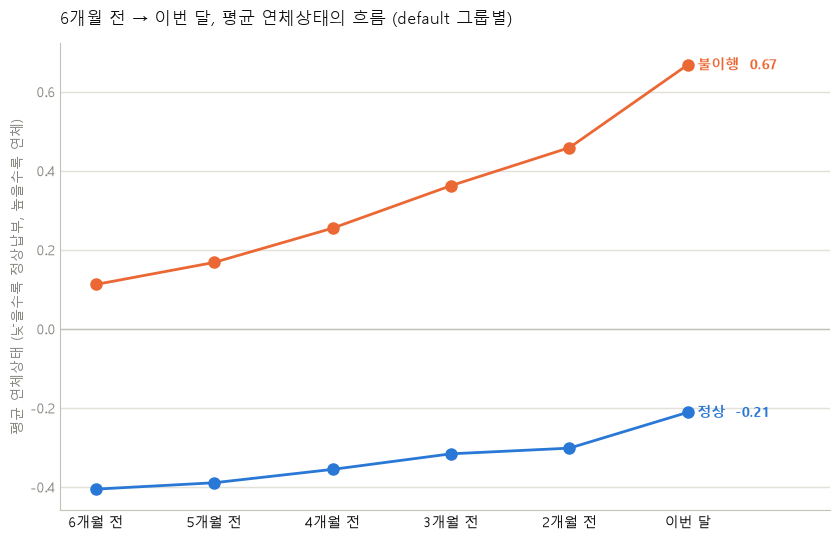

In [10]:
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

정상색 = "#2a78d6"
불이행색 = "#eb6834"
GRID = "#e1e0d9"
AXIS = "#c3c2b7"
MUTED = "#898781"
INK = "#0b0b0b"

fig, ax = plt.subplots(figsize=(8.5, 5.5))

x = range(len(피벗))
ax.plot(x, 피벗["정상(0)"], color=정상색, linewidth=2, marker="o", markersize=8, zorder=3, label="정상(0)")
ax.plot(x, 피벗["불이행(1)"], color=불이행색, linewidth=2, marker="o", markersize=8, zorder=3, label="불이행(1)")

ax.axhline(0, color=AXIS, linewidth=1, zorder=1)
ax.yaxis.grid(True, color=GRID, linewidth=1, zorder=0)
ax.set_axisbelow(True)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
ax.spines["left"].set_color(AXIS)
ax.spines["bottom"].set_color(AXIS)

ax.set_xticks(list(x))
ax.set_xticklabels(피벗["월"], color=INK)
ax.tick_params(axis="y", colors=MUTED, length=0)
ax.tick_params(axis="x", length=0)

# 마지막 지점 옆에 직접 값을 적어 범례 없이도 바로 읽히게 한다
ax.text(len(x) - 1 + 0.08, 피벗["정상(0)"].iloc[-1], f"정상  {피벗['정상(0)'].iloc[-1]:.2f}",
         va="center", color=정상색, fontsize=10, fontweight="bold")
ax.text(len(x) - 1 + 0.08, 피벗["불이행(1)"].iloc[-1], f"불이행  {피벗['불이행(1)'].iloc[-1]:.2f}",
         va="center", color=불이행색, fontsize=10, fontweight="bold")

ax.set_xlim(-0.3, len(x) - 1 + 1.2)
ax.set_title("6개월 전 → 이번 달, 평균 연체상태의 흐름 (default 그룹별)",
             fontsize=12, color=INK, loc="left", pad=14)
ax.set_ylabel("평균 연체상태 (낮을수록 정상납부, 높을수록 연체)", color=MUTED, fontsize=10)

fig.tight_layout()
plt.show()

### 알게 된 것 (실행 결과 기준, 비전문가용 설명)

**먼저 숫자 하나를 어떻게 읽는지부터.** `PAY_0~PAY_6`는 "그 달에 카드값을 얼마나 늦게 냈는지"를 적어둔 값이다. 0 이하(0, -1, -2)면 제때 냈거나 카드를 거의 안 쓴 달이고, 1 이상이면 그 숫자만큼 개월 수를 밀려서 냈다는 뜻이다(이 값의 뜻 자체는 이 프로젝트 데이터 안에 적혀 있지 않고, 이 데이터셋을 설명하는 외부 문서를 바탕으로 한 것임을 밝힌다). 그래서 "평균 연체상태"가 크다는 건 그만큼 밀려서 낸 달이 많았다는 뜻이다.

**표로 확인한 것**: 6개월 전부터 이번 달까지 한 줄씩 펼쳐서(180000행 = 30000명 × 6개월) 달마다 평균을 낸 결과가 위 표다.
- 정상 납부자(정상 그룹)는 6개월 내내 평균이 마이너스(-0.41 ~ -0.21)다 — 즉 밀린 적이 거의 없고, 그마저도 6개월 동안 거의 안 바뀐다.
- 다음 달에 카드값을 못 갚게 될 사람들(불이행 그룹)은 6개월 전에도 이미 평균이 플러스(0.11)였고, 이번 달엔 0.67까지 계속 올라간다 — **시작부터 이미 연체가 있었고, 달이 갈수록 점점 더 늦게 낸다.**

**한 사람 단위로 다시 확인**: 각 고객의 "초반 3개월 평균"과 "후반 3개월 평균"을 비교했더니, 정상 그룹은 -0.38 → -0.28로 거의 그대로인데, 불이행 그룹은 0.18 → 0.50으로 확 나빠진다(차이 0.32, 정상 그룹의 약 3배). 그리고 "후반이 초반보다 나빠진 사람"의 비율도 불이행 그룹이 45.1%로 정상 그룹(26.1%)보다 뚜렷이 많다.

**한 줄 요약**: 다음 달에 카드값을 못 갚는 사람은 어느 날 갑자기 그렇게 되는 게 아니라, **6개월 전부터 이미 조금씩 늦게 내기 시작해서 점점 더 심해지는 흐름**이 데이터에 나타난다.

## Q8. 이상탐지로 답 없이 찾기 (lab13과 같은 방식)

In [11]:
from sklearn.ensemble import IsolationForest

# lab13과 똑같이 contamination=0.05, random_state=42. 정답(y)은 넣지 않는다
탐지기 = IsolationForest(contamination=0.05, random_state=42)
지목 = 탐지기.fit_predict(X)
이상 = (지목 == -1)

잡은것 = (이상 & (y == 1)).sum()
print("지목 건수:", 이상.sum())
print("그중 실제 불이행:", 잡은것)
print("지목 중 진짜:", round(잡은것 / 이상.sum() * 100, 1), "%")
print("전체 불이행 중 잡은 것:", round(잡은것 / (y == 1).sum() * 100, 1), "%")
print("(견줄 값) 전체 불이행률:", round(y.mean() * 100, 2), "%")

# 같은 건수를 이상탐지 없이 무작위로 뽑았다면 어땠을지 견줘본다
무작위 = y.sample(n=이상.sum(), random_state=42)
print()
print(f"무작위로 같은 {이상.sum()}건을 뽑았을 때 그중 불이행:", (무작위 == 1).sum(),
      f"({round((무작위 == 1).mean() * 100, 1)}%)")

지목 건수: 1500
그중 실제 불이행: 481
지목 중 진짜: 32.1 %
전체 불이행 중 잡은 것: 7.2 %
(견줄 값) 전체 불이행률: 22.12 %

무작위로 같은 1500건을 뽑았을 때 그중 불이행: 338 (22.5%)


### 알게 된 것 (실행 결과 기준, 비전문가용 설명)

**이상탐지가 하는 일을 한 줄로.** IsolationForest는 정답(불이행 여부)을 전혀 보지 않고, "다수와 많이 다르게 생긴 사람"만 골라낸다. lab13에서 이 방법으로 SECOM 불량품을 찾아봤는데, 이번엔 같은 방식을 신용카드 고객에게 그대로 적용해봤다.

**결과**: 전체 30000명 중 5%인 1500명을 "이상하다"고 지목했더니, 그중 481명(32.1%)이 실제로 다음 달 카드값을 못 갚은 사람이었다. 언뜻 괜찮아 보이지만, **같은 1500명을 그냥 제비뽑기(무작위)로 뽑았어도 22.5%(338명)는 불이행자였을 것**이다. 즉 이상탐지가 무작위보다 나은 정도는 32.1 ÷ 22.5 ≈ **1.4배**뿐이다.

**왜 SECOM 때와 다른가.** SECOM에서는 이상탐지(15.2%)가 무작위(6.3%)보다 약 2.4배 잘 맞았다. 차이가 나는 이유는 간단하다 — **"이상하다"는 방법은 원래 드문 것을 찾는 도구인데, 이 데이터는 불이행자가 22%나 돼서 더 이상 "드문 사람들"이 아니기 때문**이다. 100명 중 5명 정도만 유별난 SECOM 불량품과 달리, 100명 중 22명이 불이행자인 여기서는 "다수와 다르게 생긴 사람"과 "카드값을 못 갚을 사람"이 서로 잘 안 겹친다.

**한 줄 요약**: 이상탐지는 "정말 드문 것"을 찾을 때 잘 통하는 방법이라, 불이행 비율이 22%나 되는 이 데이터에서는 Q5의 지도학습(가중치 준 로지스틱, 재현율 0.607)만큼 힘을 못 쓴다 — **비율이 얼마나 드문가에 따라 같은 방법이라도 효과가 크게 달라진다**는 걸 두 데이터를 나란히 돌려보고 확인했다.

## 정리 — 이 실습은 무엇이었나

| 질문 | 답 |
|---|---|
| 무엇을 맞히는 문제인지 | 카드 고객이 다음 달 대금을 못 갚을지(불이행 여부)를 미리 맞히는 문제 |
| 결과 열로 무엇을 쓰면 되는지 | `default payment next month` (0=정상 상환, 1=불이행) |
| 현장에서 누가 그 판단에 쓸지 | 카드사 여신심사·리스크관리 부서 — 청구서 발송 전 위험 고객을 골라 한도 조정, 연체 전 상담·알림, 채권 회수 우선순위 결정에 활용 |